In [ ]:
import os
from google.colab import drive
from IPython.display import Image, display

# Mount Google Drive for persistent outputs
drive.mount('/content/drive')

# Define paths
PROJECT_ROOT = '/content/vae-scale-study'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
HF_CACHE_DIR = os.path.join(PROJECT_ROOT, 'hf_cache')
OUTPUTS_DIR = '/content/drive/MyDrive/vae-scale-study/outputs'

# Create directories
dirs_to_create = [
    PROJECT_ROOT,
    DATA_DIR,
    HF_CACHE_DIR,
    OUTPUTS_DIR,
    os.path.join(PROJECT_ROOT, 'configs'),
    os.path.join(PROJECT_ROOT, 'src', 'models'),
    os.path.join(PROJECT_ROOT, 'notebooks'),
]

for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)

print("Directory structure created successfully.")

Mounted at /content/drive
Directory structure created successfully.


In [ ]:
%%writefile /content/vae-scale-study/requirements.txt
torch
torchvision
numpy
pandas
matplotlib
scikit-learn
tqdm
PyYAML
datasets
huggingface_hub
Pillow

Writing /content/vae-scale-study/requirements.txt


In [ ]:
%%writefile /content/vae-scale-study/configs/cifar100.yaml
dataset: cifar100
data_source: torchvision
data_dir: /content/vae-scale-study/data
image_size: 64
latent_dim: 128
batch_size: 128
epochs: 50
lr: 0.001
weight_decay: 0.0001
beta: 1.0
reconstruction_loss: mse
num_workers: 2
mixed_precision: true
output_dir: /content/drive/MyDrive/vae-scale-study/outputs/cifar100
seed: 42

Writing /content/vae-scale-study/configs/cifar100.yaml


In [ ]:
%%writefile /content/vae-scale-study/configs/tinyimagenet.yaml
dataset: tinyimagenet
data_source: huggingface
hf_dataset_name: zh-plus/tiny-imagenet
data_dir: /content/vae-scale-study/data
hf_cache_dir: /content/vae-scale-study/hf_cache
image_size: 64
latent_dim: 128
batch_size: 64
epochs: 30
lr: 0.001
weight_decay: 0.0001
beta: 1.0
reconstruction_loss: mse
num_workers: 2
mixed_precision: true
output_dir: /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet
seed: 42

Writing /content/vae-scale-study/configs/tinyimagenet.yaml


In [ ]:
%%writefile /content/vae-scale-study/src/datasets.py
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.datasets import CIFAR100

try:
    from datasets import load_dataset
except ImportError:
    load_dataset = None

class TinyImageNetHFDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image']
        label = item['label']
        if image.mode != 'RGB':
            image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def get_dataloaders(config):
    image_size = config.get('image_size', 64)
    batch_size = config.get('batch_size', 128)
    num_workers = config.get('num_workers', 2)
    data_dir = config.get('data_dir', '/content/vae-scale-study/data')

    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor()
    ])

    if config['dataset'] == 'cifar100':
        train_dataset = CIFAR100(root=data_dir, train=True, download=True, transform=transform)
        val_dataset = CIFAR100(root=data_dir, train=False, download=True, transform=transform)
    elif config['dataset'] == 'tinyimagenet':
        if load_dataset is None:
            raise ImportError("Please install the 'datasets' library to load Tiny ImageNet from Hugging Face.")
        hf_cache_dir = config.get('hf_cache_dir', '/content/vae-scale-study/hf_cache')
        hf_dataset_name = config.get('hf_dataset_name', 'zh-plus/tiny-imagenet')

        dataset = load_dataset(hf_dataset_name, cache_dir=hf_cache_dir)
        train_dataset = TinyImageNetHFDataset(dataset['train'], transform=transform)
        val_dataset = TinyImageNetHFDataset(dataset['valid'], transform=transform)
    else:
        raise ValueError(f"Unknown dataset: {config['dataset']}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

Writing /content/vae-scale-study/src/datasets.py


In [ ]:
%%writefile /content/vae-scale-study/src/models/conv_vae.py
import torch
import torch.nn as nn

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder (64x64 -> 32x32 -> 16x16 -> 8x8 -> 4x4)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, 256 * 4 * 4)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 256, 4, 4)
        return self.decoder_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

Writing /content/vae-scale-study/src/models/conv_vae.py


In [ ]:
%%writefile /content/vae-scale-study/src/losses.py
import torch
import torch.nn.functional as F

def vae_loss_fn(recon_x, x, mu, logvar, beta=1.0, recon_type='mse'):
    # Normalize losses per image
    if recon_type == 'mse':
        recon_loss = F.mse_loss(recon_x, x, reduction='none')
        recon_loss = recon_loss.view(recon_loss.size(0), -1).sum(dim=1).mean()
    else:
        recon_loss = F.binary_cross_entropy(recon_x, x, reduction='none')
        recon_loss = recon_loss.view(recon_loss.size(0), -1).sum(dim=1).mean()

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

Writing /content/vae-scale-study/src/losses.py


In [ ]:
%%writefile /content/vae-scale-study/train.py
import os
import yaml
import argparse
import pandas as pd
import torch
from tqdm import tqdm
from src.datasets import get_dataloaders
from src.models.conv_vae import ConvVAE
from src.losses import vae_loss_fn

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--config', type=str, required=True)
    args = parser.parse_args()

    with open(args.config, 'r') as f:
        config = yaml.safe_load(f)

    os.makedirs(config['output_dir'], exist_ok=True)
    torch.manual_seed(config.get('seed', 42))
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_loader, val_loader = get_dataloaders(config)
    model = ConvVAE(latent_dim=config['latent_dim']).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])

    metrics = []
    best_val_loss = float('inf')

    for epoch in range(1, config['epochs'] + 1):
        model.train()
        train_loss, train_recon, train_kl = 0., 0., 0.
        for x, _ in tqdm(train_loader, desc=f"Epoch {epoch} Train"):
            x = x.to(device)
            optimizer.zero_grad()
            recon_x, mu, logvar = model(x)
            loss, recon, kl = vae_loss_fn(recon_x, x, mu, logvar, config['beta'], config['reconstruction_loss'])
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            train_recon += recon.item() * x.size(0)
            train_kl += kl.item() * x.size(0)

        n_train = len(train_loader.dataset)
        train_loss /= n_train
        train_recon /= n_train
        train_kl /= n_train

        model.eval()
        val_loss, val_recon, val_kl = 0., 0., 0.
        with torch.no_grad():
            for x, _ in tqdm(val_loader, desc=f"Epoch {epoch} Val"):
                x = x.to(device)
                recon_x, mu, logvar = model(x)
                loss, recon, kl = vae_loss_fn(recon_x, x, mu, logvar, config['beta'], config['reconstruction_loss'])
                val_loss += loss.item() * x.size(0)
                val_recon += recon.item() * x.size(0)
                val_kl += kl.item() * x.size(0)

        n_val = len(val_loader.dataset)
        val_loss /= n_val
        val_recon /= n_val
        val_kl /= n_val

        print(f"Epoch {epoch}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        metrics.append({
            'epoch': epoch,
            'train_loss': train_loss, 'train_recon': train_recon, 'train_kl': train_kl,
            'val_loss': val_loss, 'val_recon': val_recon, 'val_kl': val_kl,
            'val_elbo': -(val_recon + val_kl)
        })

        pd.DataFrame(metrics).to_csv(os.path.join(config['output_dir'], 'metrics.csv'), index=False)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(config['output_dir'], 'best_model.pt'))

if __name__ == '__main__':
    main()

Writing /content/vae-scale-study/train.py


In [ ]:
%%writefile /content/vae-scale-study/linear_probe.py
import os
import yaml
import argparse
import torch
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from src.datasets import get_dataloaders
from src.models.conv_vae import ConvVAE

def extract_features(loader, model, device):
    model.eval()
    features, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            mu, _ = model.encode(x)
            features.append(mu.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--config', type=str, required=True)
    parser.add_argument('--checkpoint', type=str, required=True)
    args = parser.parse_args()

    with open(args.config, 'r') as f:
        config = yaml.safe_load(f)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_loader, val_loader = get_dataloaders(config)

    model = ConvVAE(latent_dim=config['latent_dim']).to(device)
    model.load_state_dict(torch.load(args.checkpoint, map_location=device))

    print("Extracting features...")
    X_train, y_train = extract_features(train_loader, model, device)
    X_val, y_val = extract_features(val_loader, model, device)

    print("Training linear probe...")
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    acc = clf.score(X_val, y_val)
    print(f"Validation Accuracy: {acc * 100:.2f}%")

    results = pd.DataFrame([{'dataset': config['dataset'], 'accuracy': acc}])
    results.to_csv(os.path.join(config['output_dir'], 'linear_probe_results.csv'), index=False)

if __name__ == '__main__':
    main()

Writing /content/vae-scale-study/linear_probe.py


### Run Experiments

Run the following cell to start training your VAEs on the datasets and running linear probes.

In [ ]:
%%writefile /content/vae-scale-study/evaluate.py
import os
import yaml
import argparse
import numpy as np
import torch
from torchvision.utils import save_image
from src.datasets import get_dataloaders
from src.models.conv_vae import ConvVAE
from src.losses import vae_loss_fn

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--config', type=str, required=True)
    parser.add_argument('--checkpoint', type=str, required=True)
    args = parser.parse_args()

    with open(args.config, 'r') as f:
        config = yaml.safe_load(f)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    _, val_loader = get_dataloaders(config)

    model = ConvVAE(latent_dim=config['latent_dim']).to(device)
    model.load_state_dict(torch.load(args.checkpoint, map_location=device))
    model.eval()

    val_loss, val_recon, val_kl = 0., 0., 0.
    all_mus, all_labels = [], []

    print("Evaluating on validation set...")
    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(val_loader):
            x = x.to(device)
            recon_x, mu, logvar = model(x)
            loss, recon, kl = vae_loss_fn(recon_x, x, mu, logvar, config['beta'], config['reconstruction_loss'])

            val_loss += loss.item() * x.size(0)
            val_recon += recon.item() * x.size(0)
            val_kl += kl.item() * x.size(0)

            all_mus.append(mu.cpu().numpy())
            all_labels.append(y.numpy())

            if batch_idx == 0:
                n = min(x.size(0), 16)
                comparison = torch.cat([x[:n], recon_x[:n]])
                save_image(comparison.cpu(), os.path.join(config['output_dir'], 'reconstruction.png'), nrow=n)

        # Random samples
        sample_z = torch.randn(64, config['latent_dim']).to(device)
        samples = model.decode(sample_z).cpu()
        save_image(samples, os.path.join(config['output_dir'], 'random_samples.png'), nrow=8)

    n_val = len(val_loader.dataset)
    print(f"Val Total Loss: {val_loss / n_val:.4f}")
    print(f"Val Recon Loss: {val_recon / n_val:.4f}")
    print(f"Val KL Loss: {val_kl / n_val:.4f}")
    print(f"Val ELBO: {-(val_recon + val_kl) / n_val:.4f}")

    all_mus = np.concatenate(all_mus, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    np.savez(os.path.join(config['output_dir'], 'latents.npz'), mu=all_mus, labels=all_labels)
    print("Saved latents and generated images.")

if __name__ == '__main__':
    main()

Writing /content/vae-scale-study/evaluate.py


In [ ]:
%%writefile /content/vae-scale-study/generate_samples.py
import os
import yaml
import argparse
import torch
from torchvision.utils import save_image
from src.datasets import get_dataloaders
from src.models.conv_vae import ConvVAE

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--config', type=str, required=True)
    parser.add_argument('--checkpoint', type=str, required=True)
    args = parser.parse_args()

    with open(args.config, 'r') as f:
        config = yaml.safe_load(f)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ConvVAE(latent_dim=config['latent_dim']).to(device)
    model.load_state_dict(torch.load(args.checkpoint, map_location=device))
    model.eval()

    _, val_loader = get_dataloaders(config)
    images, _ = next(iter(val_loader))
    images = images.to(device)

    with torch.no_grad():
        mu, _ = model.encode(images)
        x1_mu, x2_mu = mu[0], mu[1]

        alphas = torch.linspace(0, 1, steps=10).to(device)
        interpolated_z = torch.stack([(1 - a) * x1_mu + a * x2_mu for a in alphas])
        interpolated_images = model.decode(interpolated_z)

        grid = torch.cat([
            images[0].unsqueeze(0),
            interpolated_images,
            images[1].unsqueeze(0)
        ])
        save_image(grid.cpu(), os.path.join(config['output_dir'], 'interpolation.png'), nrow=12)
        print(f"Saved latent interpolation to {config['output_dir']}/interpolation.png")

if __name__ == '__main__':
    main()

Writing /content/vae-scale-study/generate_samples.py


In [ ]:
%%writefile /content/vae-scale-study/make_plots.py
import os
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_metrics(metrics_path, output_dir):
    df = pd.read_csv(metrics_path)

    plt.figure(figsize=(10, 5))
    plt.plot(df['epoch'], df['train_loss'], label='Train Total Loss')
    plt.plot(df['epoch'], df['val_loss'], label='Val Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(os.path.join(output_dir, 'total_loss.png'))
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.plot(df['epoch'], df['train_recon'], label='Train Recon')
    plt.plot(df['epoch'], df['val_recon'], label='Val Recon')
    plt.xlabel('Epoch')
    plt.ylabel('Reconstruction Loss')
    plt.legend()
    plt.savefig(os.path.join(output_dir, 'recon_loss.png'))
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.plot(df['epoch'], df['train_kl'], label='Train KL')
    plt.plot(df['epoch'], df['val_kl'], label='Val KL')
    plt.xlabel('Epoch')
    plt.ylabel('KL Loss')
    plt.legend()
    plt.savefig(os.path.join(output_dir, 'kl_loss.png'))
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.scatter(df['val_kl'], df['val_recon'], c=df['epoch'], cmap='viridis')
    plt.colorbar(label='Epoch')
    plt.xlabel('Validation KL Loss')
    plt.ylabel('Validation Recon Loss')
    plt.title('KL vs Recon Tradeoff')
    plt.savefig(os.path.join(output_dir, 'kl_vs_recon.png'))
    plt.close()

def plot_latents(latents_path, output_dir):
    data = np.load(latents_path)
    mu, labels = data['mu'], data['labels']

    pca = PCA(n_components=2)
    mu_pca = pca.fit_transform(mu)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(mu_pca[:, 0], mu_pca[:, 1], c=labels, cmap='tab20', alpha=0.6, s=10)
    plt.colorbar(scatter)
    plt.title('PCA of VAE Latent Means')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.savefig(os.path.join(output_dir, 'latent_pca.png'))
    plt.close()

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--run_dir', type=str, required=True)
    args = parser.parse_args()

    metrics_path = os.path.join(args.run_dir, 'metrics.csv')
    latents_path = os.path.join(args.run_dir, 'latents.npz')

    if os.path.exists(metrics_path):
        plot_metrics(metrics_path, args.run_dir)
        print("Metrics plotted.")

    if os.path.exists(latents_path):
        plot_latents(latents_path, args.run_dir)
        print("Latent PCA plotted.")

if __name__ == '__main__':
    main()

Writing /content/vae-scale-study/make_plots.py


In [ ]:
%%writefile /content/vae-scale-study/README.md
# VAE Dataset Scale Study: CIFAR-100 vs Tiny ImageNet

## Overview
This repository investigates the question: **How does dataset complexity affect the tradeoff between reconstruction quality, latent regularization, and semantic organization in VAEs trained using AEVB?**

We train Auto-Encoding Variational Bayes (AEVB) convolutional Variational Autoencoders (VAEs) on two distinct datasets:
- **CIFAR-100**: 100 classes, 32x32 native resolution (resized to 64x64)
- **Tiny ImageNet**: 200 classes, 64x64 native resolution

By comparing these, we aim to understand how the scale of visual complexity directly impacts ELBO decomposition, KL regularization, reconstruction fidelity, and downstream linear classification.

## How to Run

**1. Setup & Mount Google Drive**
In a Colab cell, run:
```python
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/vae-scale-study/data
!mkdir -p /content/vae-scale-study/hf_cache
!mkdir -p /content/drive/MyDrive/vae-scale-study/outputs
```

**2. Training**
```bash
!python train.py --config configs/cifar100.yaml
!python train.py --config configs/tinyimagenet.yaml
```

**3. Evaluation (Loss & Latent extraction)**
```bash
!python evaluate.py --config configs/cifar100.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/cifar100/best_model.pt
!python evaluate.py --config configs/tinyimagenet.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/best_model.pt
```

**4. Linear Probe (Semantic Organization)**
```bash
!python linear_probe.py --config configs/cifar100.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/cifar100/best_model.pt
!python linear_probe.py --config configs/tinyimagenet.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/best_model.pt
```

**5. Visualizations & Plots**
```bash
!python make_plots.py --run_dir /content/drive/MyDrive/vae-scale-study/outputs/cifar100
!python make_plots.py --run_dir /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet
!python generate_samples.py --config configs/tinyimagenet.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/best_model.pt


Writing /content/vae-scale-study/README.md


In [ ]:
# Change directory to project root
%cd /content/vae-scale-study

# Install required libraries
!pip install -r requirements.txt

# Run training and linear probe for CIFAR-100
!python train.py --config configs/cifar100.yaml
!python linear_probe.py --config configs/cifar100.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/cifar100/best_model.pt

# Run training and linear probe for Tiny ImageNet
!python train.py --config configs/tinyimagenet.yaml
!python linear_probe.py --config configs/tinyimagenet.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/best_model.pt

/content/vae-scale-study
100% 169M/169M [00:02<00:00, 58.9MB/s]
Epoch 1 Train: 100% 391/391 [00:09<00:00, 40.31it/s]
Epoch 1 Val: 100% 79/79 [00:01<00:00, 45.30it/s]
Epoch 1: Train Loss: 400.0146, Val Loss: 281.5543
Epoch 2 Train: 100% 391/391 [00:08<00:00, 47.36it/s]
Epoch 2 Val: 100% 79/79 [00:01<00:00, 45.58it/s]
Epoch 2: Train Loss: 223.0538, Val Loss: 202.8366
Epoch 3 Train: 100% 391/391 [00:08<00:00, 47.06it/s]
Epoch 3 Val: 100% 79/79 [00:01<00:00, 49.12it/s]
Epoch 3: Train Loss: 194.7852, Val Loss: 192.2588
Epoch 4 Train: 100% 391/391 [00:08<00:00, 46.19it/s]
Epoch 4 Val: 100% 79/79 [00:01<00:00, 48.99it/s]
Epoch 4: Train Loss: 184.8048, Val Loss: 182.2355
Epoch 5 Train: 100% 391/391 [00:08<00:00, 45.50it/s]
Epoch 5 Val: 100% 79/79 [00:01<00:00, 49.46it/s]
Epoch 5: Train Loss: 177.1025, Val Loss: 173.8951
Epoch 6 Train: 100% 391/391 [00:08<00:00, 44.80it/s]
Epoch 6 Val: 100% 79/79 [00:01<00:00, 52.14it/s]
Epoch 6: Train Loss: 170.3172, Val Loss: 170.2946
Epoch 7 Train: 100% 391/

In [ ]:
# Change directory to project root
%cd /content/vae-scale-study

# Run evaluation for CIFAR-100
!python evaluate.py --config configs/cifar100.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/cifar100/best_model.pt

/content/vae-scale-study
Evaluating on validation set...
Val Total Loss: 168.5694
Val Recon Loss: 112.5056
Val KL Loss: 56.0638
Val ELBO: -168.5694
Saved latents and generated images.


In [ ]:
# Change directory to project root
%cd /content/vae-scale-study

# Run evaluation for Tiny ImageNet
!python evaluate.py --config configs/tinyimagenet.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/best_model.pt

/content/vae-scale-study
Evaluating on validation set...
Val Total Loss: 313.2351
Val Recon Loss: 239.4213
Val KL Loss: 73.8138
Val ELBO: -313.2351
Saved latents and generated images.


In [ ]:
# Change directory to project root
%cd /content/vae-scale-study

# Make plots for CIFAR-100
!python make_plots.py --run_dir /content/drive/MyDrive/vae-scale-study/outputs/cifar100

# Make plots for Tiny ImageNet
!python make_plots.py --run_dir /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet

/content/vae-scale-study
Metrics plotted.
Latent PCA plotted.
Metrics plotted.
Latent PCA plotted.


In [ ]:
# Change directory to project root
%cd /content/vae-scale-study

# Generate latent interpolations for CIFAR-100
!python generate_samples.py --config configs/cifar100.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/cifar100/best_model.pt

/content/vae-scale-study
Saved latent interpolation to /content/drive/MyDrive/vae-scale-study/outputs/cifar100/interpolation.png


In [ ]:
# Change directory to project root
%cd /content/vae-scale-study

# Generate latent interpolations for Tiny ImageNet
!python generate_samples.py --config configs/tinyimagenet.yaml --checkpoint /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/best_model.pt


/content/vae-scale-study
Saved latent interpolation to /content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/interpolation.png


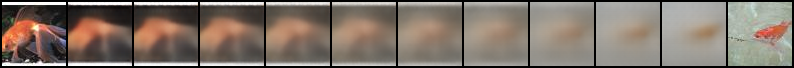

In [ ]:
# Display the latent interpolation for Tiny ImageNet
image_path = '/content/drive/MyDrive/vae-scale-study/outputs/tinyimagenet/interpolation.png'
display(Image(filename=image_path))